# House Price Prediction


Dataset: **House Price Prediction** from Kaggle (`Housing.csv`)

Link: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset

### Setup and Data Loading

In [1]:
#Import Necessary Libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib.ticker import ScalarFormatter
import warnings
warnings.filterwarnings("ignore")
plt.style.use("default")
sns.set(font_scale=1.1)

In [2]:

df= pd.read_csv('/Users/sadikurrahmankhan/Documents/Machine Learning Projects/House Price Prediction using Streamlit/Housing.csv')
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
copy_df = df

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
# To see all unique value from specific feature
df['furnishingstatus'].unique()

array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)

## Binary Encoding/Label Encoding for Binary Features 

In [7]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({
        'yes': 1,
        'no': 0
    })

## Ordinal Encoding for 'furnishingstatus' feature

In [8]:
furnishing_order = {
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
}

df['furnishingstatus'] = df['furnishingstatus'].map(furnishing_order)

In [9]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


In [10]:
# Filter the dataset for area = 2000
filtered_df = df[df['area'] == 2000]

# Display the price for area = 2000
print(filtered_df[['area', 'price']])

# Find the maximum and minimum values for 'area' and 'price'
max_area = df['area'].max()
min_area = df['area'].min()

max_price = df['price'].max()
min_price = df['price'].min()

# Display the results
print(f"Maximum Area: {max_area}, Minimum Area: {min_area}")
print(f"Maximum Price: {max_price}, Minimum Price: {min_price}")


#to look out for spefic value
df[df['price'] == 13300000]

     area    price
498  2000  2660000
Maximum Area: 16200, Minimum Area: 1650
Maximum Price: 13300000, Minimum Price: 1750000


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2


# Exploratory Data Analysis

<Axes: xlabel='price', ylabel='Density'>

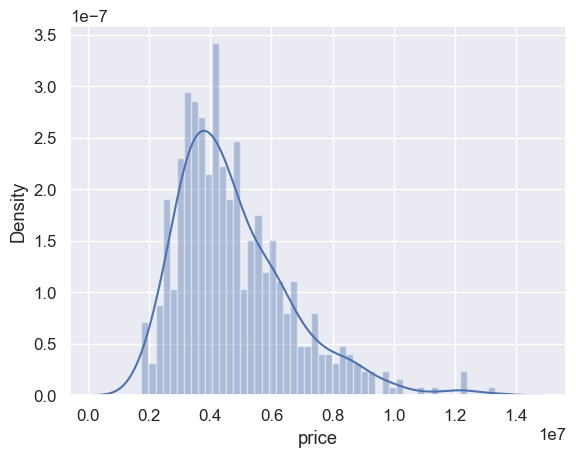

In [11]:
sns.distplot(df['price'],bins=50)

### Scatter plot of area vs price

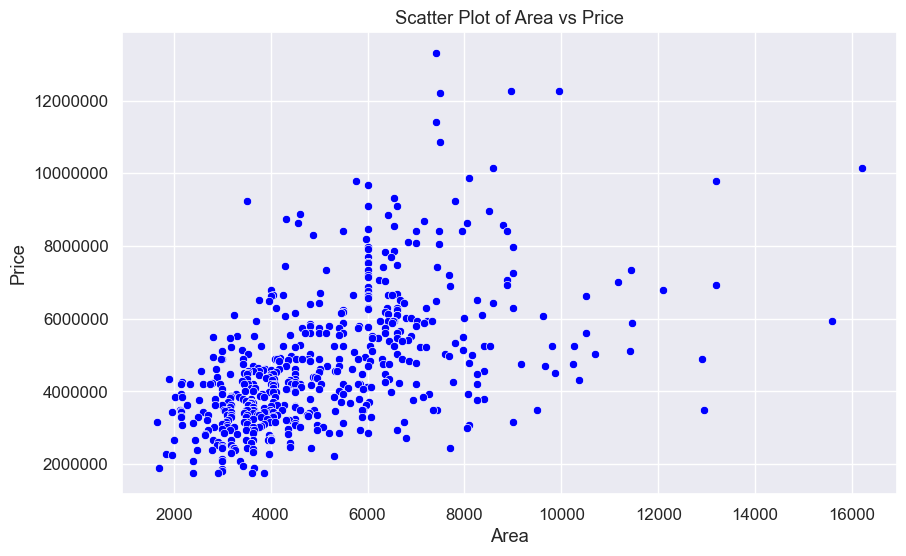

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='area', y='price', data=df, color='blue')

plt.title('Scatter Plot of Area vs Price')

plt.xlabel('Area')
plt.ylabel('Price')

# Ensure y-axis displays the actual price values without scientific notation

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))  # Disable scientific notation
ax.ticklabel_format(style='plain', axis='y')  # Set plain formatting for y-axis

plt.show()


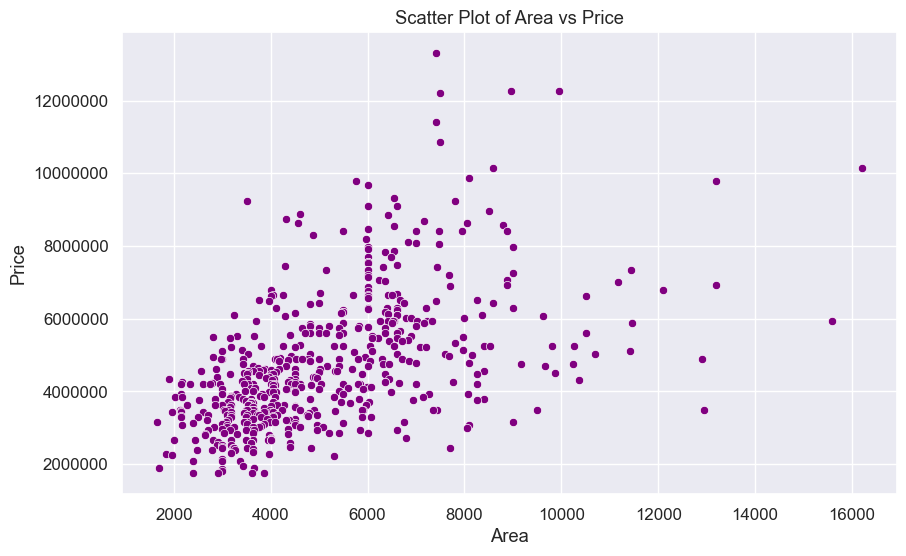

In [13]:

# Scatter plot using seaborn
plt.figure(figsize=(10,6))
sns.scatterplot(x='area', y='price', data=df, color='purple')
plt.title('Scatter Plot of Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')

# Ensure y-axis displays the actual price values without scientific notation

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))  # Disable scientific notation

ax.ticklabel_format(style='plain', axis='y')  # Set plain formatting for y-axis

plt.show()


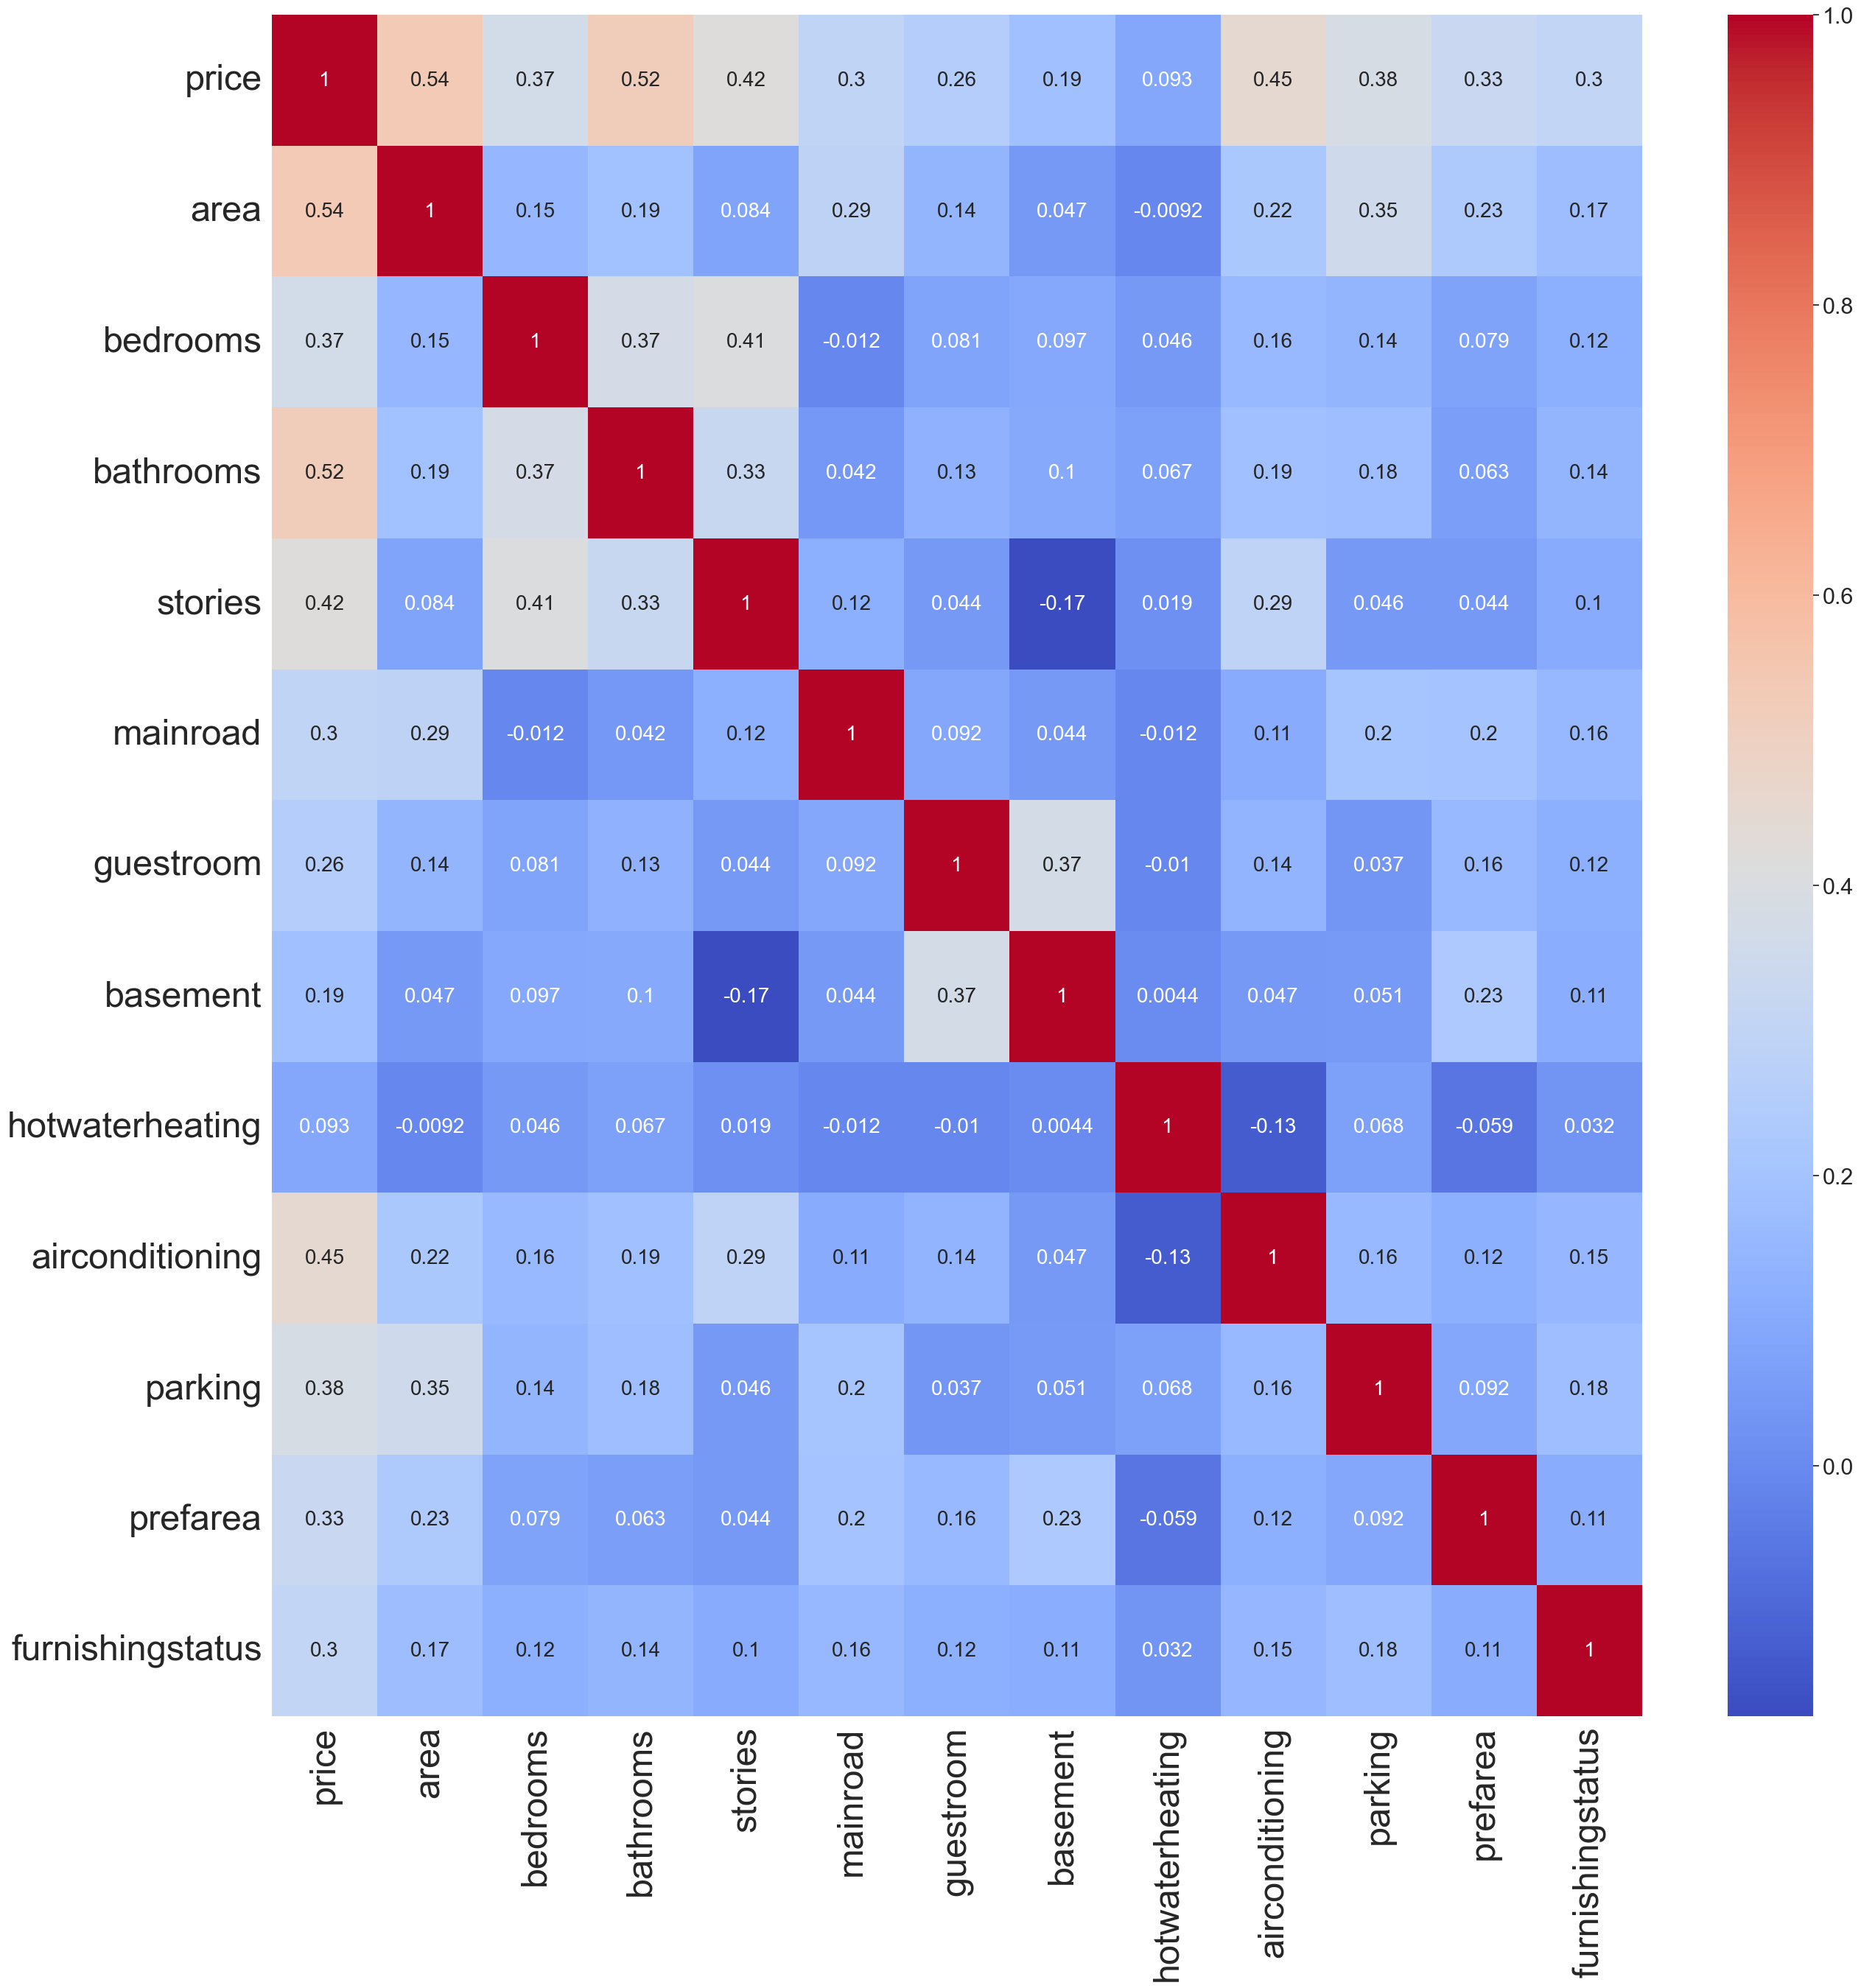

In [14]:
#now let's go for heatmap

sns.set(font_scale=2)
plt.subplots(figsize=(30,30))
heat_plot=sns.heatmap(df.corr(method='pearson'), annot=True, cmap='coolwarm',annot_kws={'size':20})
plt.yticks(fontsize=35)
plt.xticks(fontsize=35)

plt.show()